In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os

downloads = os.path.join(os.path.expanduser("~"), "Downloads")

filename = os.path.join(downloads, "TC_OP_tau.npz")

data = np.load(filename)

# extract arrays
N_arr = data["N"]
tau = data["tau"]
E_ergo = data["Eerg"]
E_var = data["variance"]
E_ratio = data["ratio"]
E_B = data["Eb"]

# derived quantities
F_ratio = np.sqrt(E_var) / E_ergo
FE_ratio = np.sqrt(E_var) / E_B

In [3]:


for i in range(len(N_arr)):
    print(
        f"N={N_arr[i]}, "
        f"τ={tau[i]:.6f}, "
        f"Eb={E_B[i]:.6f}, "
        f"Ergotropy={E_ergo[i]:.6f}, "
        f"Ratio={E_ratio[i]:.6f}, "
        f"Variance={E_var[i]:.10e},"
        f"Fluctuation w.r.t erg={F_ratio[i]:.10e},"
        f"Fluctuation w.r.t EB={FE_ratio[i]:.10e}"
    )

N=2, τ=0.500000, Eb=0.729245, Ergotropy=0.720765, Ratio=0.988372, Variance=4.8151552327e-01,Fluctuation w.r.t erg=9.6274526484e-01,Fluctuation w.r.t EB=9.5155021251e-01
N=4, τ=0.500000, Eb=2.253860, Ergotropy=2.208202, Ratio=0.979742, Variance=1.1820892122e+00,Fluctuation w.r.t erg=4.9236414483e-01,Fluctuation w.r.t EB=4.8238990417e-01
N=6, τ=0.500000, Eb=4.078653, Ergotropy=3.967672, Ratio=0.972790, Variance=1.8745826175e+00,Fluctuation w.r.t erg=3.4507740907e-01,Fluctuation w.r.t EB=3.3568781285e-01
N=8, τ=0.500000, Eb=6.004933, Ergotropy=5.808980, Ratio=0.967368, Variance=2.5616536130e+00,Fluctuation w.r.t erg=2.7552456555e-01,Fluctuation w.r.t EB=2.6653365553e-01
N=10, τ=0.500000, Eb=7.944190, Ergotropy=7.653851, Ratio=0.963453, Variance=3.2688157180e+00,Fluctuation w.r.t erg=2.3621919739e-01,Fluctuation w.r.t EB=2.2758601433e-01
N=12, τ=0.500000, Eb=9.853419, Ergotropy=9.468207, Ratio=0.960906, Variance=4.0334814218e+00,Fluctuation w.r.t erg=2.1211544889e-01,Fluctuation w.r.t EB=2

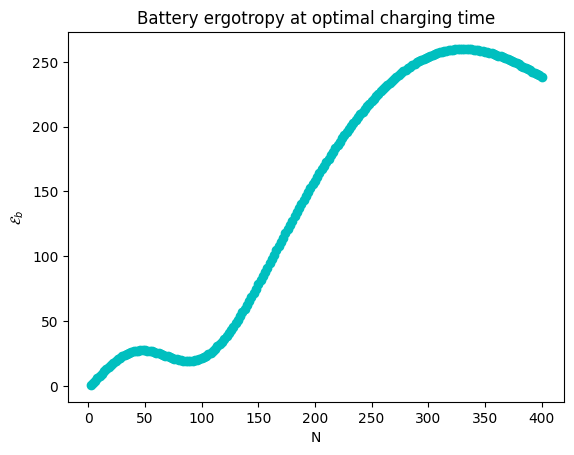

In [4]:
###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

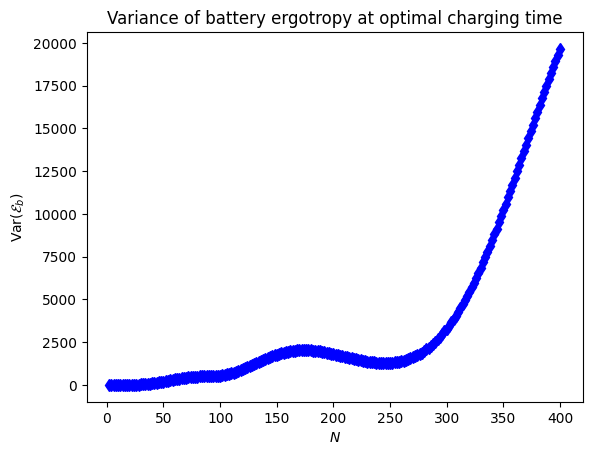

In [5]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.show()

### Scaling of $1 - \mathcal{E}_b / \langle E_b \rangle$

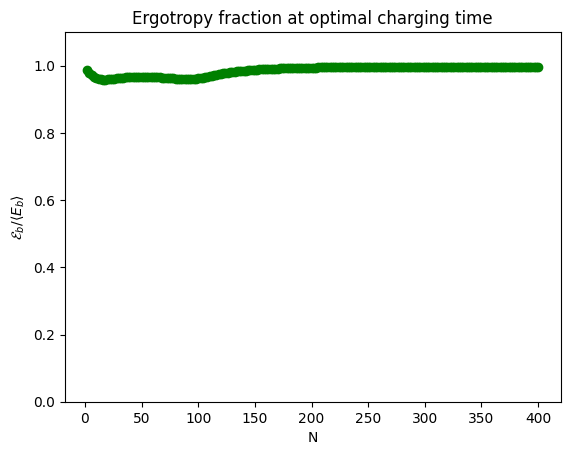

In [6]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

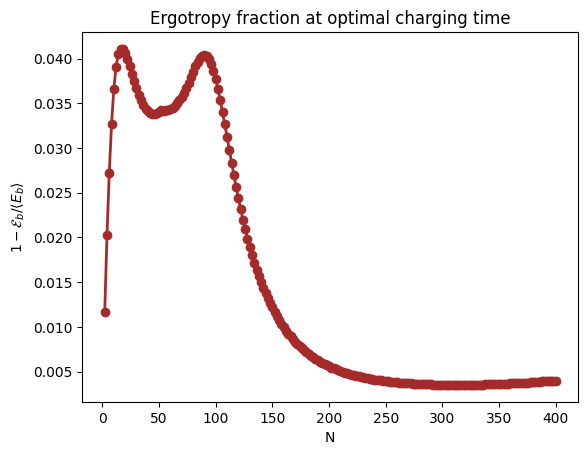

In [7]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, 1 - E_ratio, 'o-', color='brown', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

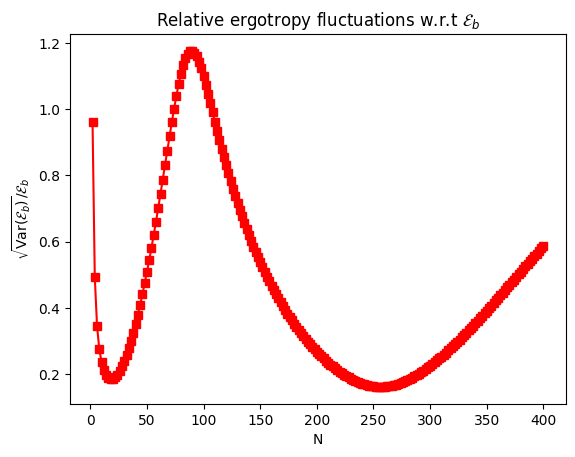

In [8]:
######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.show()

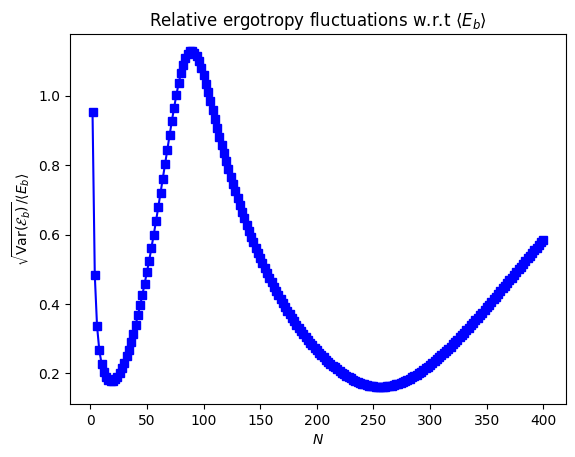

In [9]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.show()

### Scaling of $ 1 - \mathcal{E}_b/\langle{E}_b \rangle $

Range [110:200] (N range: 222 to 400)  -->  alpha = 0.178252
Range [120:200] (N range: 242 to 400)  -->  alpha = -0.000139
Range [130:200] (N range: 262 to 400)  -->  alpha = -0.165381
Range [140:200] (N range: 282 to 400)  -->  alpha = -0.319586
Range [150:200] (N range: 302 to 400)  -->  alpha = -0.467342
Range [160:200] (N range: 322 to 400)  -->  alpha = -0.611660
Range [170:200] (N range: 342 to 400)  -->  alpha = -0.739360
Range [180:200] (N range: 362 to 400)  -->  alpha = -0.846189
Range [190:200] (N range: 382 to 400)  -->  alpha = -0.996752


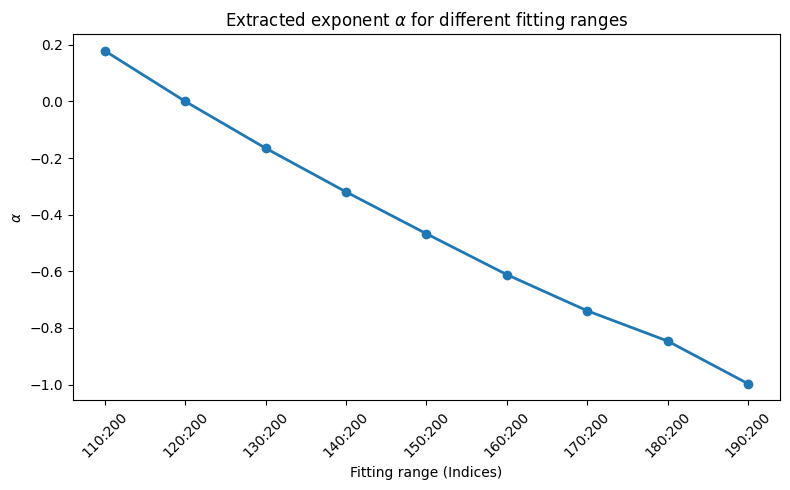

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def log_fit1(log_N, logA, alpha):
    return logA - alpha * log_N

y_full = 1 - np.array(E_ratio)

fit_ranges = [
    (110, 200),
    (120, 200),
    (130, 200),
    (140, 200),
    (150, 200),
    (160, 200),
    (170, 200),
    (180, 200),
    (190, 200)
]

alpha_list = []
range_labels = []

for start, end in fit_ranges:
    N_data = N_arr[start:end]
    y_data = y_full[start:end]

    mask = (N_data > 0) & (y_data > 0)

    N_fit = N_data[mask]
    y_fit = y_data[mask]

    if len(N_fit) < 3:
        print(f"Skipping range [{start}:{end}] because it contains only {len(N_fit)} elements.")
        continue

    log_N = np.log(N_fit)
    log_y = np.log(y_fit)

    popt, _ = curve_fit(log_fit1, log_N, log_y)
    alpha = popt[1]

    alpha_list.append(alpha)
    range_labels.append(f"{start}:{end}")

    print(f"Range [{start}:{end}] (N range: {N_fit[0]} to {N_fit[-1]})  -->  alpha = {alpha:.6f}")

# -----------------------------------
# Alpha vs fitting range Plot
# -----------------------------------
plt.figure(figsize=(8,5))
plt.plot(range(len(alpha_list)), alpha_list, 'o-', lw=2, color='tab:blue')
plt.xticks(range(len(range_labels)), range_labels, rotation=45)
plt.xlabel("Fitting range (Indices)")
plt.ylabel(r"$\alpha$")
plt.title(r"Extracted exponent $\alpha$ for different fitting ranges")
plt.tight_layout()
plt.show()

Best fit parameter: A = 0.000101, alpha = -0.611660


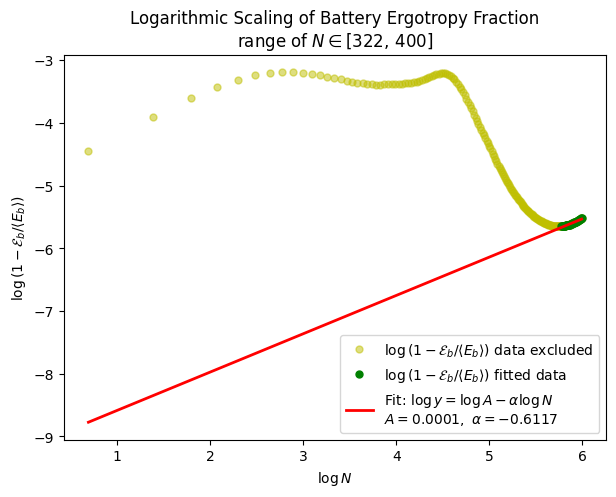

In [11]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit1(log_N, logA, alpha1):
    return logA - alpha1 *log_N

y_full = 1 - np.array(E_ratio)

# Restrict fitting data
N_data1 = N_arr[160:200]
y_data1 = y_full[160:200]

# Keep only positive values for the logarithm
mask = (N_data1 > 0) & (y_data1 > 0)

N_fit1 = N_data1[mask]
y_fit_data1 = y_data1[mask]

# Logarithmic variables
log_N = np.log(N_fit1)
log_y = np.log(y_fit_data1)

# Fit in log-space
popt, pcov = curve_fit(log_fit1, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ fitted data")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log A - \alpha \log N$'
        '\n'
        rf'$A={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")
plt.title(
    rf"Logarithmic Scaling of Battery Ergotropy Fraction"
    "\n"
    rf"range of $N \in [{N_fit1[0]},\, {N_fit1[-1]}]$"
)
plt.legend()
plt.show()

### Scaling of $\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$

Range [110:200] (N range: 222 to 400)  -->  alpha = -2.397187
Range [120:200] (N range: 242 to 400)  -->  alpha = -2.946020
Range [130:200] (N range: 262 to 400)  -->  alpha = -3.285651
Range [140:200] (N range: 282 to 400)  -->  alpha = -3.396615
Range [150:200] (N range: 302 to 400)  -->  alpha = -3.359080
Range [160:200] (N range: 322 to 400)  -->  alpha = -3.248464
Range [170:200] (N range: 342 to 400)  -->  alpha = -3.101689
Range [180:200] (N range: 362 to 400)  -->  alpha = -2.932111
Range [190:200] (N range: 382 to 400)  -->  alpha = -2.742677


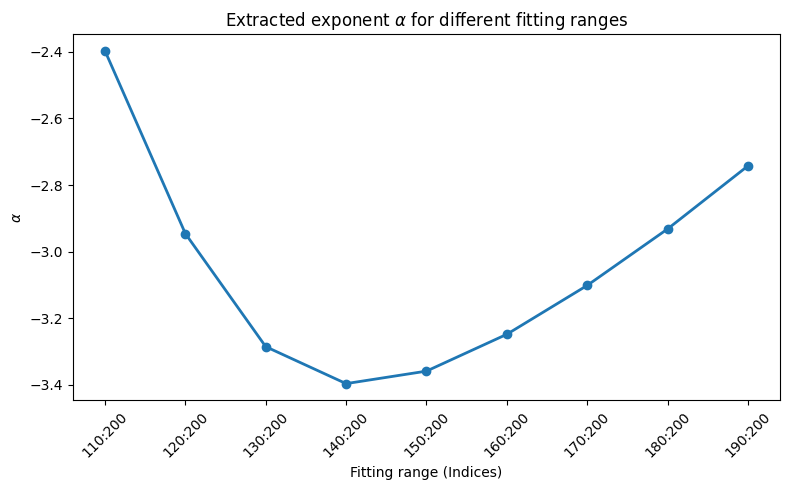

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def log_fit2(log_N, logA, alpha):
    return logA - alpha * log_N

y_full = np.array(F_ratio)

fit_ranges = [
    (110, 200),
    (120, 200),
    (130, 200),
    (140, 200),
    (150, 200),
    (160, 200),
    (170, 200),
    (180, 200),
    (190, 200)
]

alpha_list = []
range_labels = []

for start, end in fit_ranges:
    N_data = N_arr[start:end]
    y_data = y_full[start:end]

    mask = (N_data > 0) & (y_data > 0)

    N_fit = N_data[mask]
    y_fit = y_data[mask]

    if len(N_fit) < 3:
        print(f"Skipping range [{start}:{end}] because it contains only {len(N_fit)} elements.")
        continue

    log_N = np.log(N_fit)
    log_y = np.log(y_fit)

    popt, _ = curve_fit(log_fit2, log_N, log_y)
    alpha = popt[1]

    alpha_list.append(alpha)
    range_labels.append(f"{start}:{end}")

    print(f"Range [{start}:{end}] (N range: {N_fit[0]} to {N_fit[-1]})  -->  alpha = {alpha:.6f}")

# -----------------------------------
# Alpha vs fitting range Plot
# -----------------------------------
plt.figure(figsize=(8,5))
plt.plot(range(len(alpha_list)), alpha_list, 'o-', lw=2, color='tab:blue')
plt.xticks(range(len(range_labels)), range_labels, rotation=45)
plt.xlabel("Fitting range (Indices)")
plt.ylabel(r"$\alpha$")
plt.title(r"Extracted exponent $\alpha$ for different fitting ranges")
plt.tight_layout()
plt.show()

Best fit parameter: A = 0.000000, alpha = -3.248464


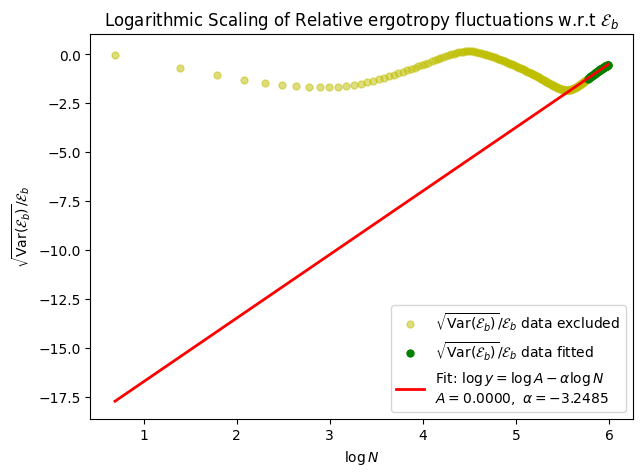

In [13]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit2(log_N, logA, alpha2):
    return logA - alpha2 *log_N

y_full = np.array(F_ratio)

# Restrict fitting data
N_data2 = N_arr[160:200]
y_data2 = y_full[160:200]

# Keep only positive values for the logarithm
mask = (N_data2 > 0) & (y_data2 > 0)

N_fit2 = N_data2[mask]
y_fit_data2 = y_data2[mask]

# Logarithmic variables
log_N = np.log(N_fit2)
log_y = np.log(y_fit_data2)

# Fit in log-space
popt, pcov = curve_fit(log_fit2, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data fitted")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log A - \alpha \log N$'
        '\n'
        rf'$A={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Logarithmic Scaling of Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.legend()
plt.show()